In [1]:
#!sudo python ../setup.py develop

In [2]:
from slowfast.config.defaults import assert_and_infer_cfg
from slowfast.utils.parser import load_config, parse_args

In [3]:
import cv2
from IPython.display import clear_output

In [4]:
import time

import numpy as np
import torch
import tqdm

from slowfast.utils import logging
from slowfast.visualization.async_predictor import AsyncDemo, AsyncVis, draw_predictions
from slowfast.visualization.ava_demo_precomputed_boxes import (
    AVAVisualizerWithPrecomputedBox,
)
from slowfast.visualization.demo_loader import ThreadVideoManager, VideoManager
from slowfast.visualization.predictor import ActionPredictor, Predictor
from slowfast.visualization.video_visualizer import VideoVisualizer, ImgVisualizer

In [5]:
import matplotlib.pyplot as plt

In [6]:
import sys
sys.path.append("/home/developer/SlowFast/tools")

In [7]:
sys.argv = [
    "tools/run_net.py",  # argv[0]는 프로그램 이름 (아무거나 넣어도 됨)
    "--cfg", "../configs/Kinetics/SLOWFAST_8x8_R50.yaml",
    "--opts",
    "DEMO.ENABLE", "True",
    "DEMO.INPUT_VIDEO", "archery.mp4",       # "$INPUT" 대신 직접 경로
    "DEMO.OUTPUT_FILE", "../outputs/archery.mp4",      # "$OUTPUT" 대신 직접 경로
    "DEMO.LABEL_FILE_PATH", "../labels/kinetics_classnames.json",
    "TEST.CHECKPOINT_FILE_PATH", "../checkpoints/SLOWFAST_8x8_R50.pkl",
    "TEST.CHECKPOINT_TYPE", "caffe2",
    "TRAIN.ENABLE", "False",
]
args = parse_args() 

In [8]:
path_to_config = args.cfg_files[0]
cfg = load_config(args, path_to_config)
cfg = assert_and_infer_cfg(cfg)

In [9]:
model = Predictor(cfg)

In [10]:
# Set random seed from configs.
np.random.seed(cfg.RNG_SEED)
torch.manual_seed(cfg.RNG_SEED)
# Setup logging format.

common_classes = (
    cfg.DEMO.COMMON_CLASS_NAMES if len(cfg.DEMO.LABEL_FILE_PATH) != 0 else None
)

video_vis = VideoVisualizer(
    num_classes=cfg.MODEL.NUM_CLASSES,
    class_names_path=cfg.DEMO.LABEL_FILE_PATH,
    top_k=cfg.TENSORBOARD.MODEL_VIS.TOPK_PREDS,
    thres=cfg.DEMO.COMMON_CLASS_THRES,
    lower_thres=cfg.DEMO.UNCOMMON_CLASS_THRES,
    common_class_names=common_classes,
    colormap=cfg.TENSORBOARD.MODEL_VIS.COLORMAP,
    mode=cfg.DEMO.VIS_MODE,
)

In [11]:
def display_frames(frames):
    
    for frame in frames:
        fig, ax = plt.subplots(figsize=(12,8))
        #image_bgr = cv2.imread(seq_info["image_filenames"][frame_idx], cv2.IMREAD_COLOR)
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax.imshow(image_rgb)
        #plt.draw()
        clear_output(wait=True)
        #
        plt.show()
        #

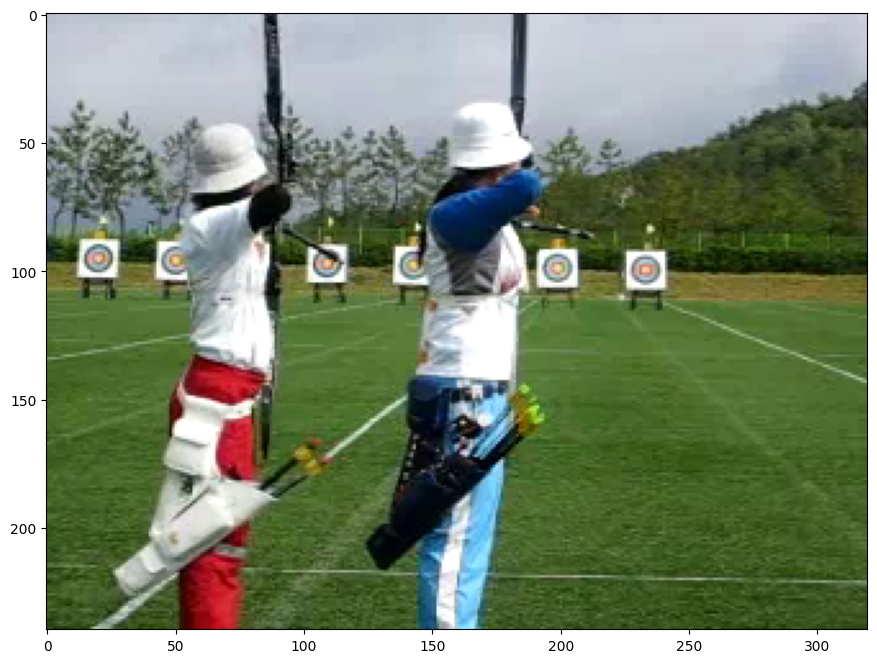

In [13]:
frame_provider = VideoManager(cfg)
frame_provider.start()

for able_to_read, task in frame_provider:
    if able_to_read:
        task = model(task)
        if task is None:
            time.sleep(0.02)
            print("task None")
            continue
        frames = draw_predictions(task, video_vis)
        task.frames = frames
        display_frames(frames)
        frame_provider.display(task)
    else:
        break
frame_provider.join()
frame_provider.clean()